# Plot GRACE SMB for Antarctica and Greenland Ice Sheets (GIS,AIS):

In [1]:
# load libraries, read time series data:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import interpolate
from numpy import linalg
from netCDF4 import Dataset
import cartopy.crs as ccrs
from datetime import datetime, timedelta
import matplotlib.patches as mpatches
import pickle
import scipy as scipy


# Import the csv datasets:
# -----------------------
# GIS index:
dir='../../../Data-for-teaching-staff/Ice-sheets/SMB-GRACE-Velicogna-2020/'
file='SM09_HUY2_120_.5_1_SPH_CAP_OCN_L60_wGSFC_C20_wGSFC_C30_wSLF_DEG1_r250km_004-213.csv'
dataset = pd.read_csv(dir+file,delim_whitespace=False,na_values='NaN' \
                      ,comment='#',skipinitialspace=True,skip_blank_lines=True,header=0)
data = np.asarray(dataset.iloc[:, :].values)
GIS_GRACE_header = dataset.iloc[:, :].columns
GIS_GRACE_years=np.asarray(data[:,2])
GIS_GRACE_SMB=np.asarray(data[:,8])
#print(GIS_GRACE_header,GIS_GRACE_years,GIS_GRACE_SMB)

# AIS index:
dir='../../../Data-for-teaching-staff/Ice-sheets/SMB-GRACE-Velicogna-2020/'
file='Ivins_R2_ANT_65_.2_1.5+ICE6G_noANT_SPH_CAP_OCN_L60_wGSFC_C20_wGSFC_C30_wSLF_DEG1_r250km_004-213.csv'
dataset = pd.read_csv(dir+file,delim_whitespace=False,na_values='NaN' \
                      ,comment='#',skipinitialspace=True,skip_blank_lines=True,header=0)
data = np.asarray(dataset.iloc[:, :].values)
AIS_GRACE_header = dataset.iloc[:, :].columns
AIS_GRACE_years=np.asarray(data[:,2])
AIS_GRACE_SMB=np.asarray(data[:,23])
#print(AIS_GRACE_header,AIS_GRACE_years,AIS_GRACE_SMB)
print("done loading libraries and data.")

done loading libraries and data.


In [7]:
# add a NaN point at 2018 to represent data gap then
AIS_GRACE_years1=np.hstack((AIS_GRACE_years[AIS_GRACE_years<2018],np.asarray(2018) \
                                ,AIS_GRACE_years[AIS_GRACE_years>2018]))
AIS_GRACE_SMB1  =np.hstack((AIS_GRACE_SMB[AIS_GRACE_years<2018]  ,np.asarray(np.nan) \
                                ,AIS_GRACE_SMB[AIS_GRACE_years>2018]))

GIS_GRACE_years1=np.hstack((GIS_GRACE_years[AIS_GRACE_years<2018],np.asarray(2018) \
                            ,GIS_GRACE_years[GIS_GRACE_years>2018]))
GIS_GRACE_SMB1  =np.hstack((GIS_GRACE_SMB[AIS_GRACE_years<2018]  ,np.asarray(np.nan) \
                            ,GIS_GRACE_SMB[GIS_GRACE_years>2018]))

# save to be pickled:
np.save("Output/to-pickle/GIS_GRACE_years.npy",GIS_GRACE_years1)
np.save("Output/to-pickle/GIS_GRACE_SMB.npy",GIS_GRACE_SMB1)
np.save("Output/to-pickle/AIS_GRACE_years.npy",AIS_GRACE_years1)
np.save("Output/to-pickle/AIS_GRACE_SMB.npy",AIS_GRACE_SMB1)
print("done.")

done.


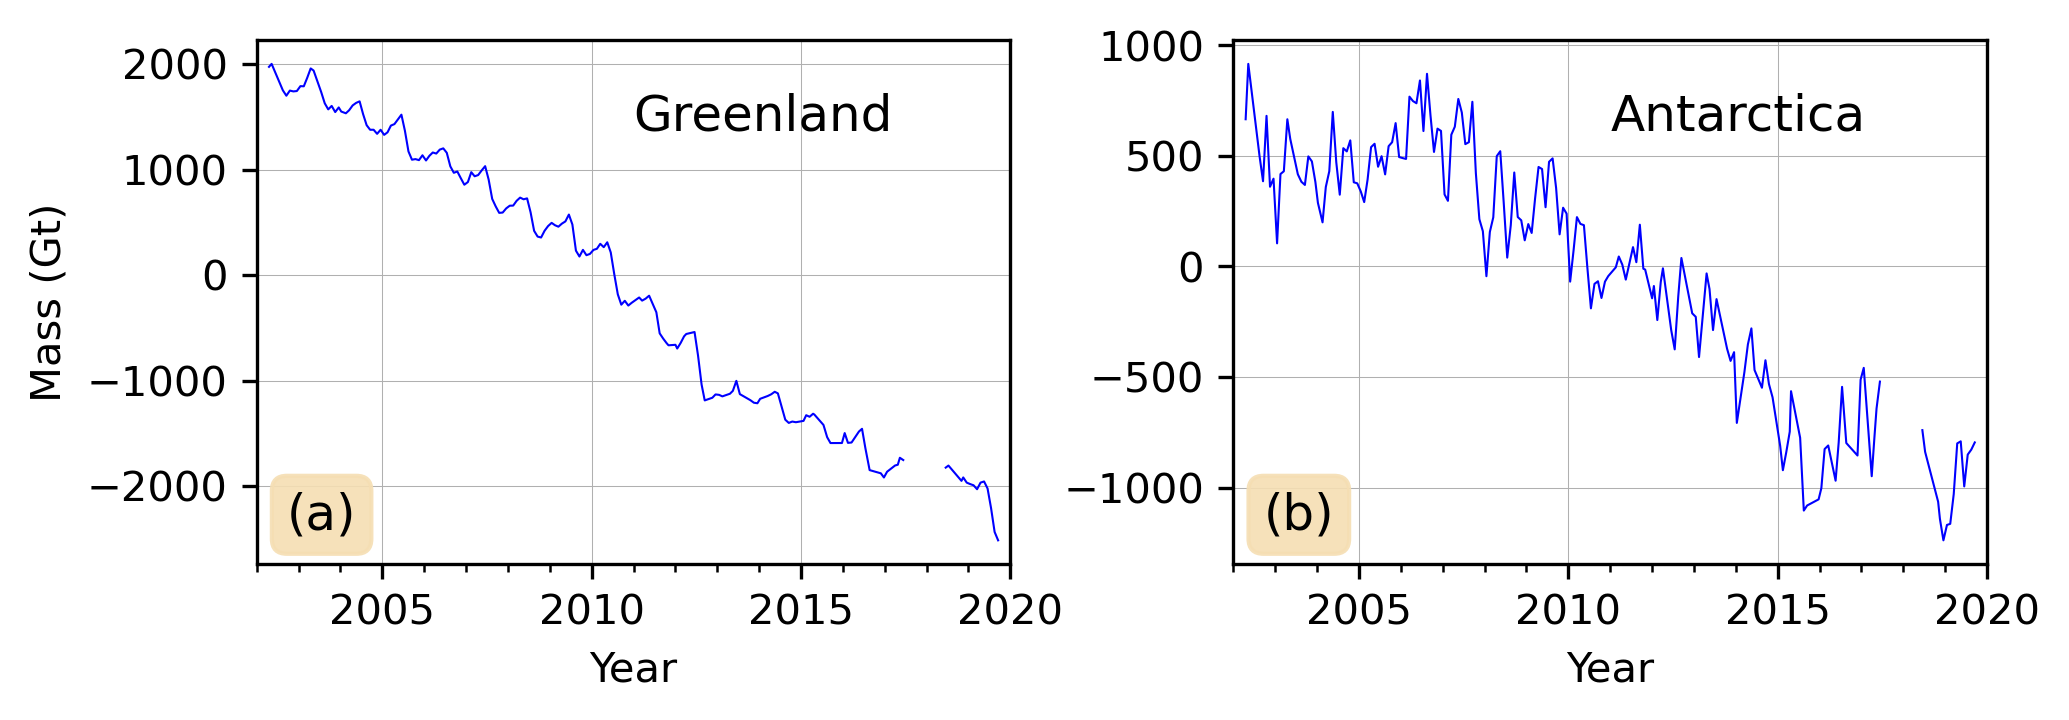

In [3]:
# plot
# for textboxes with (a), (b) etc:
props = dict(boxstyle='round', edgecolor="wheat", facecolor='wheat', alpha=0.9)

fig=plt.figure(figsize=(7,2.5),dpi=300)

plt.subplot(1,2,1)
plt.plot(GIS_GRACE_years1,GIS_GRACE_SMB1,'b',lw=0.5)
axes=plt.gca()
plt.xlabel("Year")
plt.text(0.5,0.9, "Greenland", transform=axes.transAxes, fontsize=12,
        verticalalignment='top')
plt.gca().set_xticks(np.arange(2001,2020,1), minor=True)
plt.xlim(2002,2020)
#plt.ylim(-1,1.5)
plt.ylabel("Mass (Gt)")
plt.grid(lw=0.25)
plt.text(0.04, 0.14, "(a)", transform=axes.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)


plt.subplot(1,2,2)
plt.plot(AIS_GRACE_years1,AIS_GRACE_SMB1,'b',lw=0.5)
axes=plt.gca()
plt.xlabel("Year")
plt.text(0.5,0.9, "Antarctica", transform=axes.transAxes, fontsize=12,
        verticalalignment='top')
plt.gca().set_xticks(np.arange(2001,2020,1), minor=True)
plt.xlim(2002,2020)
#plt.ylim(-1,1.5)
#plt.ylabel("AIS_GRACE SMB")
plt.grid(lw=0.25)
plt.text(0.04, 0.14, "(b)", transform=axes.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)


plt.tight_layout(w_pad=0.0)
plt.show()
fig.savefig("Output/ice-sheets-GRACE-SMB-timeseries.pdf")